# Rainbow book spot greeks: sticky-strike bumps, cross-gamma, convergence

Hedging the daily-sold rainbow book needs the spot **delta vector** and the
**gamma matrix including cross terms** — the ranked payoff couples the
underlyings, so per-underlying gammas are not enough. This notebook computes
both by central **1% bumps** in the **sticky-strike** framework (user spec
2026-08-06) and calibrates how many Sobol paths the estimates need, mirroring
the price-level path study.

**Sticky-strike bump = a different implied distribution per scenario.** Under
$S \to S(1+\varepsilon)$ with vols pinned per *strike*, the moneyness-quoted
surface must read $\sigma_{new}(m) = \sigma_{old}(m(1+\varepsilon))$ — so each
bumped index's marginal is **re-derived from the shifted smile**
(`MarginalFactory.strike_shift_dgrid`) *and* its seasoning $g$ scales by
$(1+\varepsilon)$. The alternative, sticky-moneyness, freezes the tables and
only scales $g$: the whole implied distribution rides with spot — that is what
the attribution driver's `eq` step and the autograd delta measure. In a flat
world the shift is exactly zero and the two frameworks coincide (tested).

Mechanics: base + 6 single bumps + 12 pair corners = **19 pricings** plus 6
shifted table builds per book. Engines: CRN Sobol at the **512-path book
standard** (one point-set family prices all 19 combos, so the differences
cancel sampling noise) and quadrature finite differences as the zero-variance
cross-check. One constraint drives the design: per path the payoff is
piecewise **linear** in $g$, so a pathwise/autograd second derivative through
the sampler is zero almost everywhere — **gamma must come from bumps**
(autograd remains valid, and free, for delta).

Conventions: SOLD book (the book we hold is short); greeks are w.r.t.
*relative* spot moves, quoted in **$ per 100% move** ($/100\%^2$ for gamma) —
divide by 100 (10,000) for per-1% numbers.

In [1]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

from vol_pca.data import load_surfaces
from vol_pca.rainbow import spot_panel
from vol_pca.surface import grid_lookup
from vol_pca.rainbow_torch import (MarginalFactory, QuadBatch, book_greeks,
                                   prepare_book_greeks, price_sobol_batch,
                                   rainbow_book_greeks, sobol_normals)

NAMES = ("SPX", "SX5E", "HSI")
sds = {n: load_surfaces(f"{n}_volSurface.csv") for n in NAMES}
spots = spot_panel(sds)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
fac = MarginalFactory(sds, device=DEV)
z512 = sobol_normals(256, 512, seed=1, device=DEV)
d64 = spots.index.values.astype("datetime64[D]")
print(f"device={DEV} | joint dates {len(spots)} | last {spots.index[-1].date()}")

device=cuda | joint dates 1969 | last 2026-07-31


## 1. The shifted implied distribution

`strike_shift_dgrid` samples each pillar row at $m(1+\varepsilon)$ through the
pricing spline (the vanilla `sticky_strike_dsigma` sampling, applied *before*
the table build). With the index skew downward-sloping, a +1% spot bump lowers
the vol read at every fixed strike, and the whole risk-neutral density —
not just a vol input — re-derives from the shifted smile.

max |pillar shift| = 1.074 vol pts


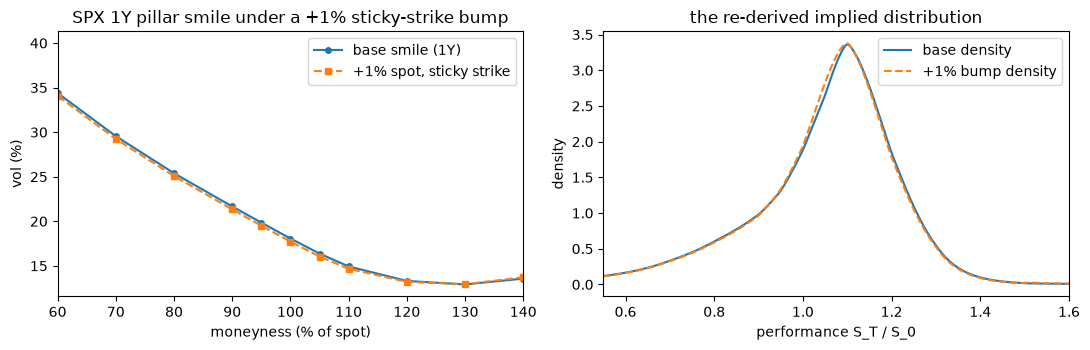

In [2]:
t_last = len(spots) - 1
di_spx = int(np.searchsorted(sds["SPX"].dates, d64[t_last]))
mon = np.asarray(sds["SPX"].moneyness, float)
row = grid_lookup(sds["SPX"].grids[di_spx], np.full(len(mon), 1.0), mon)
row_up = CubicSpline(mon, row)(np.clip(mon * 1.01, mon[0], mon[-1]))

tau1 = np.array([1.0])
xb, cb, _ = fac.tables("SPX", di_spx, tau1)
dg = fac.strike_shift_dgrid("SPX", di_spx, 0.01)
xs, cs, _ = fac.tables("SPX", di_spx, tau1, dgrid=dg)
x0, f0 = xb[0].cpu().numpy(), np.gradient(cb[0].cpu().numpy(), xb[0].cpu().numpy())
x1, f1 = xs[0].cpu().numpy(), np.gradient(cs[0].cpu().numpy(), xs[0].cpu().numpy())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(mon, 100 * row, "o-", label="base smile (1Y)", ms=4)
ax[0].plot(mon, 100 * row_up, "s--", label="+1% spot, sticky strike", ms=4)
ax[0].set(xlim=(60, 140), xlabel="moneyness (% of spot)", ylabel="vol (%)",
          title="SPX 1Y pillar smile under a +1% sticky-strike bump")
ax[0].legend()
ax[1].plot(x0, f0, label="base density")
ax[1].plot(x1, f1, "--", label="+1% bump density")
ax[1].set(xlim=(0.55, 1.6), xlabel="performance S_T / S_0",
          ylabel="density", title="the re-derived implied distribution")
ax[1].legend()
plt.tight_layout()
print(f"max |pillar shift| = {float(dg.abs().max()) * 100:.3f} vol pts")

## 2. Delta vector and gamma matrix, last date

`rainbow_book_greeks` at the 2026-07-31 book (258 vintages): sticky-strike by
CRN Sobol@512 and by quadrature FDs, sticky-moneyness for contrast, and the
autograd (pathwise) delta — which is sticky-moneyness by construction and
should match the SM bumps.

In [3]:
ss = rainbow_book_greeks(sds, fac=fac, normals=z512)
sq = rainbow_book_greeks(sds, engine="quad", fac=fac)
sm = rainbow_book_greeks(sds, mode="sticky_moneyness", fac=fac, normals=z512)

state = prepare_book_greeks(sds, mode="sticky_moneyness", device=DEV, fac=fac)
b = state["batches"]["base"]
g = b.g.clone().requires_grad_(True)
pv = price_sobol_batch(QuadBatch(x=b.x, cdf=b.cdf, psi=b.psi, chol=b.chol,
                                 g=g, df=b.df), z512, slots=state["slots"])
pv.sum().backward()
d_auto = -(g.grad * b.g).sum(0).cpu().numpy()
del state
if DEV == "cuda":
    torch.cuda.empty_cache()

delta = pd.DataFrame({"SS sobol@512": ss["delta"], "SS quad": sq["delta"],
                      "SM bump": sm["delta"], "SM autograd": d_auto},
                     index=NAMES) / 1e6
print(f"book {ss['n_pos']} options, mark ${ss['pv'] / 1e6:,.2f}M")
print("\ndelta, $M per 100% move (sold book):")
print(delta.round(2).to_string())
print(f"\nSS - SM delta gap ($M): {((ss['delta'] - sm['delta']) / 1e6).round(2)}"
      f"  |  SM bump vs autograd max rel: "
      f"{np.abs(sm['delta'] / d_auto - 1).max():.2%}")
gm = lambda a: pd.DataFrame(a / 1e6, index=NAMES, columns=NAMES).round(1)
print("\ngamma, $M per 100%^2 — sticky strike (sobol@512):")
print(gm(ss["gamma"]).to_string())
print("\nsticky strike (quad):")
print(gm(sq["gamma"]).to_string())
print("\nsticky moneyness (sobol@512):")
print(gm(sm["gamma"]).to_string())
one = np.ones(3)
print(f"\nP&L scale of a joint +1% day: delta term "
      f"${ss['delta'] @ one * 0.01 / 1e3:,.0f}k, second-order term "
      f"${0.5 * one @ ss['gamma'] @ one * 1e-4 / 1e3:,.1f}k")

book 258 options, mark $-20.64M

delta, $M per 100% move (sold book):
      SS sobol@512  SS quad  SM bump  SM autograd
SPX         -40.29   -40.39   -41.66       -41.71
SX5E        -39.19   -39.28   -39.66       -39.67
HSI         -17.61   -17.66   -18.05       -18.05

SS - SM delta gap ($M): [1.37 0.47 0.43]  |  SM bump vs autograd max rel: 0.12%

gamma, $M per 100%^2 — sticky strike (sobol@512):
        SPX   SX5E   HSI
SPX     9.5  206.8  43.8
SX5E  206.8   30.2  57.3
HSI    43.8   57.3  35.2

sticky strike (quad):
        SPX   SX5E   HSI
SPX    13.2  208.9  45.0
SX5E  208.9   34.9  58.6
HSI    45.0   58.6  37.0

sticky moneyness (sobol@512):
        SPX   SX5E   HSI
SPX    47.9  289.9  74.6
SX5E  289.9   78.6  80.6
HSI    74.6   80.6  32.9

P&L scale of a joint +1% day: delta term $-971k, second-order term $34.5k


### Reading the numbers

- **Delta**: the sold book is short ≈ $(-40.3, -39.2, -17.6)$M per 100%.
  The **framework gap** is the hedge decision: sticky-moneyness deltas are
  ~1–3.5% larger in magnitude (SPX $-41.7$ vs $-40.3$M — a $1.4M difference
  in the futures hedge). The vanilla study's verdict (delta-hedging with the
  sticky-strike delta leaves less residual risk) carried the plain-BS delta;
  this is its exact analog for the simulation book. The autograd delta
  matches the SM bumps to ≤0.12% — same framework, two routes.
- **The cross-gamma is the book's dominant convexity.** SPX–SX5E cross gamma
  ≈ **$207M/100%²** vs diagonals of only $9–35M. Mechanism: the ranked
  weights contribute $0.1\,|P_1-P_2|$, whose second derivative is a δ-ridge
  along $P_1=P_2$; with the pair this correlated the ridge carries enormous
  mass. A per-underlying (diagonal) gamma view misses it entirely — this is
  the quantitative case for the full matrix. The HSI crosses ($44–57M) are
  ordinary basket-level curvature (no rank kink against HSI).
- **Gamma depends on the framework too**: the SM diagonal SPX gamma is $48M
  vs $9.5M sticky-strike — smile-riding adds vega/curvature terms.
- Scale: on a joint +1% day the delta term is ≈ $-970$k, the full
  second-order term ≈ $+34$k; on a 5% day the latter scales ×25 — material.

## 3. Bump-size sensitivity (noise-free quadrature FDs)

Kink-concentrated gamma is really a *window-averaged* convexity: the FD
measures the ridge mass inside $\pm\varepsilon$. Delta should be
$\varepsilon$-invariant; the cross gamma mildly averaged; small diagonals the
most window-sensitive.

In [4]:
rows = {}
for eps in (0.005, 0.01, 0.02):
    q = rainbow_book_greeks(sds, eps=eps, engine="quad", fac=fac)
    rows[f"{eps:.1%}"] = {
        "delta SPX $M": q["delta"][0] / 1e6,
        "gamma SPX diag $M": q["gamma"][0, 0] / 1e6,
        "gamma SPX-SX5E $M": q["gamma"][0, 1] / 1e6,
        "gamma SPX-HSI $M": q["gamma"][0, 2] / 1e6}
print(pd.DataFrame(rows).T.round(2).to_string())

      delta SPX $M  gamma SPX diag $M  gamma SPX-SX5E $M  gamma SPX-HSI $M
0.5%        -40.40              15.84             210.09             45.03
1.0%        -40.39              13.18             208.90             44.98
2.0%        -40.32              11.62             204.34             44.86


Delta is flat to 0.2% across a 4× range of $\varepsilon$; the big cross moves
~3% (210→204); the small SPX diagonal is genuinely window-dependent
(15.8→11.6). **1% stays the standard** — quote gammas as ±1%-window
convexities, the desk convention for kinked books.

## 4. Five as-of dates — and which engine to trust on crash surfaces

In [5]:
DATES = ["2019-09-30", "2020-03-16", "2021-06-30", "2024-08-05",
         str(spots.index[-1].date())]
rows = []
for dstr in DATES:
    t = int(min(spots.index.searchsorted(dstr), len(spots) - 1))
    s = rainbow_book_greeks(sds, asof=t, fac=fac, normals=z512)
    q = rainbow_book_greeks(sds, asof=t, engine="quad", fac=fac)
    gm_ = s["gamma"] / 1e6
    rows.append({"date": s["date"].date(), "n": s["n_pos"],
                 "pv $M": s["pv"] / 1e6,
                 **{f"d {nm} $M": s["delta"][i] / 1e6
                    for i, nm in enumerate(NAMES)},
                 "g diag $M": np.round(np.diag(gm_), 1),
                 "g x(01,02,12) $M": np.round([gm_[0, 1], gm_[0, 2],
                                               gm_[1, 2]], 1),
                 "|d-quad|max $k": np.abs(s["delta"] - q["delta"]).max() / 1e3})
print(pd.DataFrame(rows).round(2).to_string(index=False))

      date   n  pv $M  d SPX $M  d SX5E $M  d HSI $M           g diag $M     g x(01,02,12) $M  |d-quad|max $k
2019-09-30 196 -10.69    -33.47     -32.64    -15.75 [-70.7, -77.5, 5.2]    [65.6, -5.9, 4.5]           55.20
2020-03-16 258  -1.58     -6.14      -4.23     -3.55  [98.2, 4.4, -10.7] [-10.1, -10.6, -8.1]         1356.09
2021-06-30 258 -22.63    -27.91     -24.01    -11.81   [18.6, 6.6, 18.4]   [90.8, 22.0, 20.3]           92.58
2024-08-05 258 -15.65    -47.89     -30.34    -18.46  [34.6, -7.2, 10.5]   [53.9, 24.0, 11.1]           64.91
2026-07-31 258 -20.64    -40.29     -39.19    -17.61   [9.5, 30.2, 35.2]  [206.8, 43.8, 57.3]           98.93


In [6]:
# crash-surface referee: quad FD delta vs ten independent Sobol families
t_cov = int(spots.index.searchsorted("2020-03-16"))
z4k = sobol_normals(256, 4096, seed=99, device=DEV)
s4k = rainbow_book_greeks(sds, asof=t_cov, fac=fac, normals=z4k, n_paths=4096)
print(f"sobol@4096 SPX delta   {s4k['delta'][0] / 1e6:+.2f}M")
for nodes in ((24, 24), (32, 32), (48, 48)):
    q = rainbow_book_greeks(sds, asof=t_cov, engine="quad",
                            quad_nodes=nodes, fac=fac)
    print(f"quad{nodes} SPX delta {q['delta'][0] / 1e6:+.2f}M")

sobol@4096 SPX delta   -6.13M


quad(24, 24) SPX delta -4.79M


quad(32, 32) SPX delta -8.18M


quad(48, 48) SPX delta -5.87M


Book-shape stories per date: the 2019 ramp book sits below its caps —
*negative* diagonal gammas ($-70/-77$M, a short-gamma book) with a $+66$M
rank cross; the COVID book's delta collapsed to $(-6.1, -4.2, -3.6)$M with a
$+98$M SPX diagonal (rebound convexity) and *negative* crosses; 2024-08-05 is
sharply asymmetric ($-47.9$ SPX vs $-30.3$ SX5E).

**Trust inversion on crash surfaces**: on 2020-03-16 the quad-FD SPX delta
oscillates $-4.8 \to -8.2 \to -5.9$M across 24²/32²/48² nodes — the
documented oscillatory node-placement tail, hitting *differences of
shifted-table prices* harder than levels — while ten independent Sobol
families agree at $-6.13 \pm 0.02$M. So: **CRN-Sobol FDs are the greeks
reference on crash surfaces**; the quadrature is the calm-date cross-check
(where the two agree to ~0.25% on delta).

## 5. Convergence: how many paths do the greeks need?

Same design as the price study: 10 independent scramble families, nested
prefixes N ∈ {64…4096} (the first $2^m$ points of a scrambled $2^{12}$ set
are a valid net), spread of the book-level greeks across the families.
Materiality yardsticks: delta noise × a 1% move, gamma noise × ½(1%)² — both
against 1bp of book notional (the price study's tolerance, $19.6–25.8$k).

In [7]:
SEEDS = range(10)
NS = [64, 128, 256, 512, 1024, 2048, 4096]
Z = [sobol_normals(256, 4096, seed=s, device=DEV) for s in SEEDS]
res = []
for dstr in DATES:
    t = int(min(spots.index.searchsorted(dstr), len(spots) - 1))
    state = prepare_book_greeks(sds, asof=t, device=DEV, fac=fac)
    for si in SEEDS:
        for n in NS:
            zc = Z[si][:, :n, :]
            gg = book_greeks(state, lambda b, sl: price_sobol_batch(
                b, zc, slots=sl))
            res.append({"date": str(state["date"].date()),
                        "n_pos": state["n_pos"], "seed": si, "N": n,
                        **{f"d{i}": gg["delta"][i] for i in range(3)},
                        **{f"g{i}{j}": gg["gamma"][i, j]
                           for i in range(3) for j in range(i, 3)}})
    del state
    if DEV == "cuda":
        torch.cuda.empty_cache()
res = pd.DataFrame(res)
print(f"{len(res)} greek sets ({len(DATES)} dates x 10 families x {len(NS)} Ns)")

350 greek sets (5 dates x 10 families x 7 Ns)


delta noise as P&L on a 1% move ($, worst element, std across families):
date  2019-09-30  2020-03-16  2021-06-30  2024-08-05  2026-07-31
N                                                               
64        1757.0      2692.0      2266.0      2098.0      1808.0
128       1462.0      1690.0       885.0      1644.0      1449.0
256        708.0      1097.0       701.0       975.0      1173.0
512        510.0       531.0       457.0       673.0       647.0
1024       262.0       214.0       279.0       268.0       474.0
2048       140.0       180.0       178.0       199.0       268.0
4096        77.0       109.0        73.0       113.0        86.0

second-order noise on a joint 1% move ($, worst gamma element):
date  2019-09-30  2020-03-16  2021-06-30  2024-08-05  2026-07-31
N                                                               
64         456.0      1693.0       666.0       527.0       713.0
128        387.0      1480.0       508.0       438.0       485.0
256        200.0 

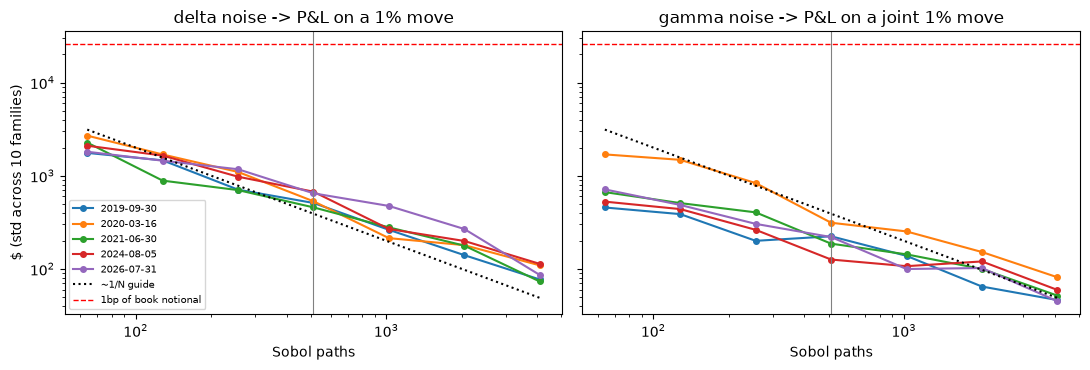

In [8]:
dcols = [f"d{i}" for i in range(3)]
gcols = [f"g{i}{j}" for i in range(3) for j in range(i, 3)]
agg = []
for (dstr, n), sub in res.groupby(["date", "N"]):
    bp = sub["n_pos"].iloc[0] * 1e6 * 1e-4
    agg.append({"date": dstr, "N": n,
                "delta P&L@1% $": sub[dcols].std().max() * 0.01,
                "gamma P&L@1% $": 0.5 * sub[gcols].std().max() * 1e-4,
                "bp": bp})
agg = pd.DataFrame(agg)
piv_d = agg.pivot(index="N", columns="date", values="delta P&L@1% $")
piv_g = agg.pivot(index="N", columns="date", values="gamma P&L@1% $")
print("delta noise as P&L on a 1% move ($, worst element, std across families):")
print(piv_d.round(0).to_string())
print("\nsecond-order noise on a joint 1% move ($, worst gamma element):")
print(piv_g.round(0).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for a, piv, ttl in ((ax[0], piv_d, "delta noise -> P&L on a 1% move"),
                    (ax[1], piv_g, "gamma noise -> P&L on a joint 1% move")):
    for c in piv.columns:
        a.loglog(piv.index, piv[c], "o-", ms=4, label=c)
    a.loglog(piv.index, 2e5 / np.asarray(piv.index, float), "k:",
             label="~1/N guide")
    a.axhline(25_800, color="r", ls="--", lw=1, label="1bp of book notional")
    a.axvline(512, color="gray", lw=0.8)
    a.set(xlabel="Sobol paths", title=ttl)
ax[0].set_ylabel("$ (std across 10 families)")
ax[0].legend(fontsize=7)
plt.tight_layout()

## Takeaways

- **512 paths is comfortably enough for the full delta + gamma matrix.** At
  the 512-path book standard the worst-date delta noise is $\le\$673$ of
  P&L per 1% move (0.026bp of book notional) and the worst gamma-element
  noise $\le\$313$ on a joint 1% day (0.012bp) — both an order of magnitude
  inside the 1bp tolerance that already governs the *price*. The greeks
  converge better than the price because every finite difference shares one
  CRN point-set family, so the common noise cancels; the path budget is set
  by the price, not the greeks.
- **The matrix costs ~19 pricings + 6 shifted table builds ≈ 0.1s per book**
  on the GPU at 512 paths — cheap enough to run daily over the whole history.
- **Sticky-strike vs sticky-moneyness is a real hedging choice**: deltas
  differ by 1–3.5% ($1.4M on SPX), gammas by multiples on the diagonal. The
  vanilla study's answer (hedge sticky-strike) transfers as the working
  default; measuring hedged-P&L risk under both delta sets on *this* book is
  the natural follow-up.
- **The rank kink makes cross-gamma the dominant convexity** ($207M/100%²
  SPX–SX5E vs $9–35M diagonals at the last date) — any VaR or hedging scheme
  built on per-underlying gammas alone would miss the book's main second-order
  risk. The coming cheap-VaR benchmark should carry the pair cross terms.
- On crash surfaces trust the CRN-Sobol finite differences over the
  quadrature FDs (oscillatory node tail); on calm dates they agree to ~0.25%
  and the quadrature remains the zero-variance cross-check.

## 6. Settling it: the sticky-strike attribution and the hedge verdict

`rainbow_attribution_ss` (user spec 2026-08-06) re-cuts the daily attribution
so the delta line *is* the sticky-strike hedge: the equity component moves all
spots to the next day the sticky-strike way (each index's implied distribution
re-derived from its moneyness-shifted smile at the realized ratio, vols pinned
per strike), and is attributed by the 1%-bump delta/gamma/cross-gamma matrix
measured on the same book and CRN points — per-index delta and gamma terms,
per-pair cross terms, and a Taylor residual. The vol component is the day's
surface change *at fixed strikes* (per-index singles + interaction residual),
`cross_ev` is the bumped equity×vol 4-corner on the totals, and theta splits
into `theta_value` (discount decay on the base pv), `theta_delta` (per-vintage
sticky-strike deltas × each vintage's forward-ratio decay) and `theta_gamma`
(the rest, folded per spec). `pl`/`time`/`fwd`/`rate` are construct-identical
to the sticky-moneyness driver (they match it to fp at equal paths/seed —
tested), so the two caches differ only in how the market move is cut.

The comparison that motivated all of this: **delta-hedged P&L under each
framework's own delta** — `pl − eq_delta` from each cache. (The caches use
2,048 vs 512 paths; the pl difference between them is pure CRN-tamed MC noise,
measured below, and immaterial at hedged-P&L scale.)

In [9]:
old = pd.read_csv("data/rainbow_attribution.csv", parse_dates=["date"],
                  index_col="date")
new = pd.read_csv("data/rainbow_attribution_ss.csv", parse_dates=["date"],
                  index_col="date")
assert (old.index == new.index).all()
h = pd.DataFrame({
    "SM delta": old["pl"] - old["eq_delta"],
    "SS delta": new["pl"] - new["eq_delta"],
    "SS delta+gamma": new["pl"] - new[["eq_delta", "eq_gamma",
                                       "eq_xgamma"]].sum(axis=1)})

def hstats(sub):
    return pd.DataFrame({
        "std $k": sub.std() / 1e3, "median $k": sub.median() / 1e3,
        "skew": sub.skew(), "worst $M": sub.min() / 1e6,
        "p1 $k": sub.quantile(0.01) / 1e3,
        "|corr ret_spx|": [abs(np.corrcoef(sub[c], new.loc[sub.index, "ret_spx"])[0, 1])
                           for c in sub.columns]}).round(2)

y2020 = h.index.year == 2020
big = new["ret_spx"].abs() > 0.02
for label, sub in (("full sample", h), ("2020", h[y2020]),
                   ("ex-2020", h[~y2020]),
                   ("big SPX days (|ret|>2%)", h[big])):
    print(f"--- {label} ({len(sub)} days) ---")
    print(hstats(sub).to_string(), "\n")
print("pl cache diff (2048 vs 512 paths): std $"
      f"{(old['pl'] - new['pl']).std():,.0f}, "
      f"max ${(old['pl'] - new['pl']).abs().max():,.0f}")

--- full sample (1968 days) ---
                std $k  median $k  skew  worst $M   p1 $k  |corr ret_spx|
SM delta        166.66       0.58 -8.35     -3.12 -499.97            0.52
SS delta         94.24      -3.67 -6.32     -1.49 -265.37            0.14
SS delta+gamma   67.27      -5.25 -1.00     -0.85 -152.49            0.08 

--- 2020 (260 days) ---
                std $k  median $k  skew  worst $M    p1 $k  |corr ret_spx|
SM delta        389.31      15.95 -4.62     -3.12 -1818.91            0.69
SS delta        213.45       3.03 -3.81     -1.49  -990.80            0.40
SS delta+gamma  128.78       6.36 -1.57     -0.85  -495.94            0.30 

--- ex-2020 (1708 days) ---
                std $k  median $k  skew  worst $M   p1 $k  |corr ret_spx|
SM delta         94.14      -1.34 -1.87     -1.02 -332.28            0.36
SS delta         56.98      -4.46 -0.61     -0.59 -157.43            0.17
SS delta+gamma   51.75      -6.97  0.62     -0.38 -137.13            0.09 

--- big SPX days (

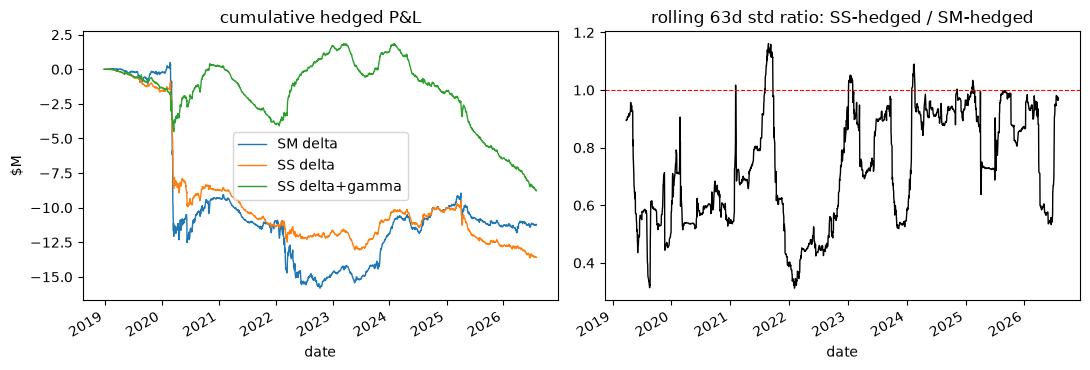

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
(h.cumsum() / 1e6).plot(ax=ax[0], lw=1)
ax[0].set(title="cumulative hedged P&L", ylabel="$M")
r = (h["SS delta"].rolling(63).std() / h["SM delta"].rolling(63).std())
r.plot(ax=ax[1], lw=1, color="k")
ax[1].axhline(1.0, color="r", ls="--", lw=0.8)
ax[1].set(title="rolling 63d std ratio: SS-hedged / SM-hedged")
plt.tight_layout()

### Verdict: the sticky-strike delta hedge wins, decisively

- **Risk**: the SS delta hedge cuts hedged-P&L std **43%** (\$166.7k →
  \$94.2k), halves the worst day (−\$3.12M → −\$1.49M), and softens the
  left tail (p1 −\$500k → −\$265k). It wins in every subsample — 2020
  (\$389k → \$213k), ex-2020 (\$94k → \$57k), big SPX days (\$530k →
  \$274k) — and on 62% of individual days.
- **The mechanism is visible in the residual market exposure**: the
  SM-hedged series still moves with SPX (|corr| **0.52**; 0.63 on big days)
  while the SS-hedged series is nearly clean (0.14). The SM delta is ~\$1.4M
  *more short* than the SS delta (the smile-slide vega term it borrows), so
  hedging with it over-shorts the book and leaves ≈ +\$1.4M·ret of market
  beta in the "hedged" P&L. That beta *earned* money over a rising market —
  which is why the SM series' cumulative (−\$11.2M) beats SS (−\$13.6M) —
  but it is unhedged market exposure, not hedging skill: realized surface
  dynamics sit far closer to sticky-strike, exactly as in the vanilla SPX
  study. The transferred verdict is now a measured one.
- **The gamma matrix explains most of what delta leaves behind**: adding the
  1%-bump gamma + cross-gamma terms takes the residual std down another 29%
  (to \$67.3k), the skew from −6.3 to **−1.0**, the worst day to −\$0.85M,
  and the big-day mean loss from −\$80k to −\$14k. (An attribution view —
  futures can't trade gamma away — but it shows the crash tail is almost
  entirely second-order equity risk, now explained rather than unexplained.)
- Honesty footnote: the two caches use 2,048 vs 512 paths; their `pl`
  difference is \$759/day std (max \$7.1k) — two orders of magnitude below
  the effects measured here.